# Application to one case

This notebook walks through a complete attribution workflow for a single Tropical Cyclone (TC) case using the `tc_track_analogues` package.


In [1]:
%load_ext line_profiler

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
from glob import glob
import pickle as pkl
from tqdm import tqdm
import os
import huracanpy

from scipy.stats import ttest_ind, cramervonmises_2samp

import tc_track_analogues as tca

## Colors
color_full = 'k'
color_cf = sns.color_palette("tab20")[0] # Blue
color_f = sns.color_palette("tab20")[2] # Orange
pal = {"CF":color_cf, "F": color_f}

## 1. Define the target

In [6]:
NAME, SEASON, BASIN = "BERTHA", 2026, "NA"
LANDFALL_TIME = "2026-07-23 00:00:00" #"2025-10-28T18:00:00"
TIME_WINDOW = 24 # in hours

In [17]:
NAME, SEASON, BASIN = "MILTON", 2024, "NA"
LANDFALL_TIME = "2024-10-09T21:00:00" #"2025-10-28T18:00:00"
TIME_WINDOW = 24 # in hours

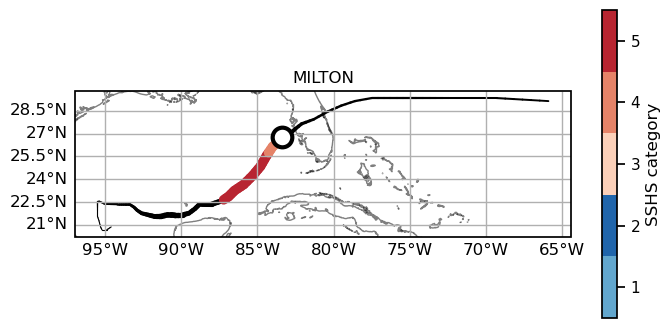

In [19]:
# Identify target case's track in IBTrACS
target = tca.load_target_track_hourly(NAME, SEASON, "NA")
landfall = target.sel(time = LANDFALL_TIME)
target_window = tca.extract_target_window_before_landfall(
                                        target, LANDFALL_TIME, TIME_WINDOW
                                        )
# Visualise the target
tca.plot_target_case(target, target_window, landfall, NAME)

## 2. Define the catalogues

In [8]:
catalogues = {
    "IBTrACS":tca.load_ibtracs_catalogue(BASIN, update = False),
    "CHAZ":tca.load_CHAZ_catalogue(),
    "MIT":tca.load_MIT_catalogue(),
    "SEAS520C":tca.load_SEAS520C_catalogue(),
}

/Users/sbourdin/miniforge3/envs/tc-track-analogues/lib/python3.14/site-packages/huracanpy/_data/_csv.py:65: DtypeWarning: Columns (21,139,159) have mixed types. Specify dtype option on import or set low_memory=False.
  tracks = load_function(filename, **kwargs)
/Users/sbourdin/miniforge3/envs/tc-track-analogues/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
## Parameters associated to the catalogues
parameters = pd.DataFrame({
    "index":['IBTrACS', 'CHAZ', 'MIT', 'SEAS520C'],
    "intensity_cols": # Intensity parameters available 
        [['wind', 'pres'], 
         ['wind'], 
         ['wind'],
         ['wind', 'pres']],
    "dates": # Period boundaries
        [[1950, 1984, 1985, 2019], 
         [1950, 1984, 1985, 2019], 
         [1950, 1984, 1985, 2019], 
         [1901, 1955, 1956, 2010], 
        ],
    "exclusion_dist": # Distance beyond which a point is not considered at all
        [1000, 300, 300, 300],
    "d_max": # Maximum analogue distance 
        [3.,1., 1., 1.5]
}).set_index("index")

## 3. Compute analogues

100%|██████████| 4/4 [00:06<00:00,  1.57s/it]


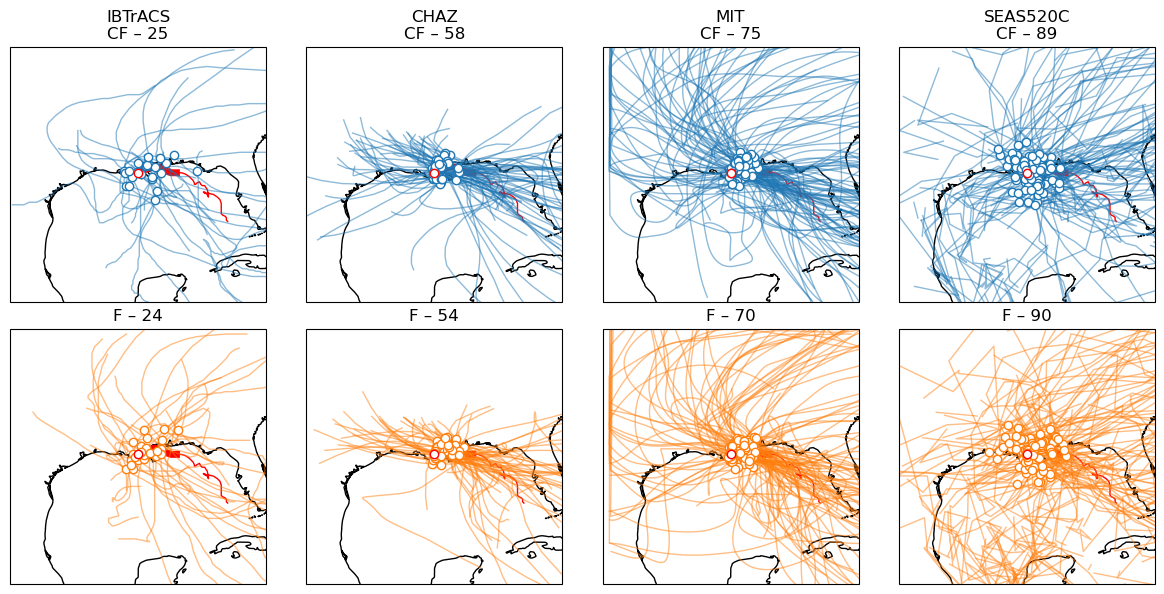

In [10]:
# Compute distance to target event
for c in tqdm(catalogues):
    if "dist2target" not in list(catalogues[c].variables.keys()):
        catalogues[c]["dist2target"] = tca.add_dist_from_target_landfall(catalogues[c], landfall.lon.values, landfall.lat.values)
# Compute analogues
analogues = {c: tca.find_analogues(target_window, catalogues[c], parameters.loc[c]) for c in tqdm(catalogues)}
# Visualise
_ = tca.plot_analogues(analogues, catalogues, target, target_window, landfall, color_cf, color_f)

## 4. Analyse differences between periods' analogues

In [11]:
sns.set_context("notebook")

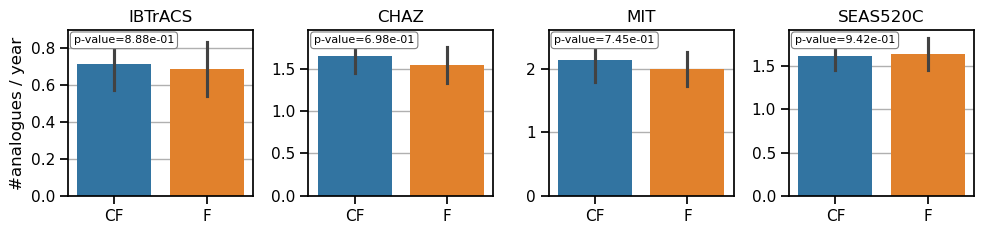

In [12]:
# Difference in number of analogues
p_freq = tca.plot_diff_in_freq(analogues, parameters, pal)

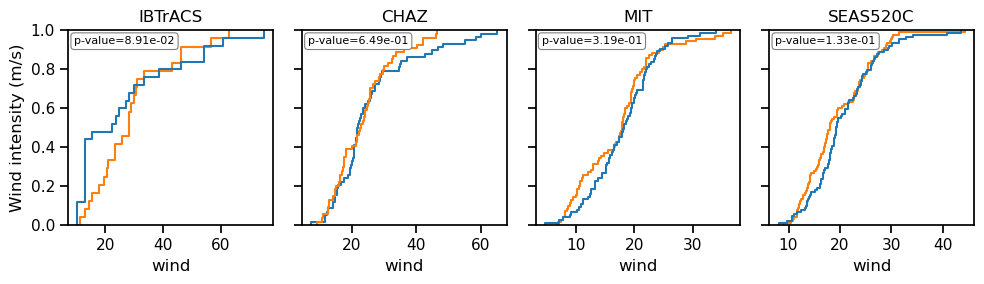

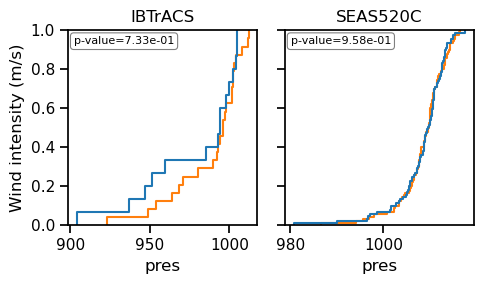

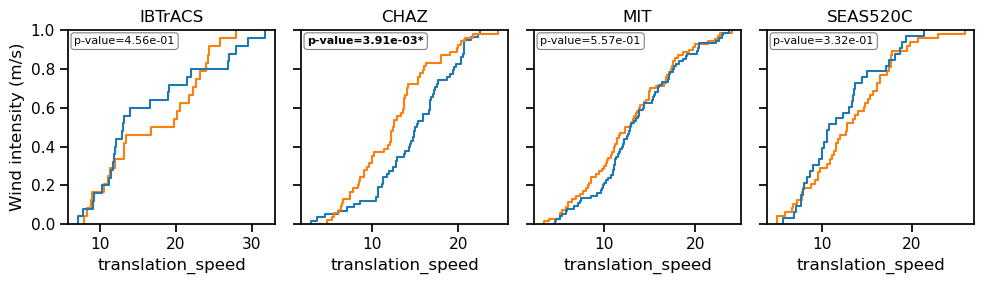

In [13]:
# Differences in intensity
p_wind = tca.plot_diff_in_intensity(analogues, pal, "wind", "ecdf")
p_pres = tca.plot_diff_in_intensity(analogues, pal, "pres", "ecdf")
p_speed = tca.plot_diff_in_intensity(analogues, pal, "translation_speed", "ecdf")

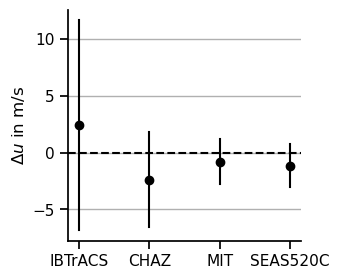

In [14]:
tca.plot_summary_diff_wind(analogues)

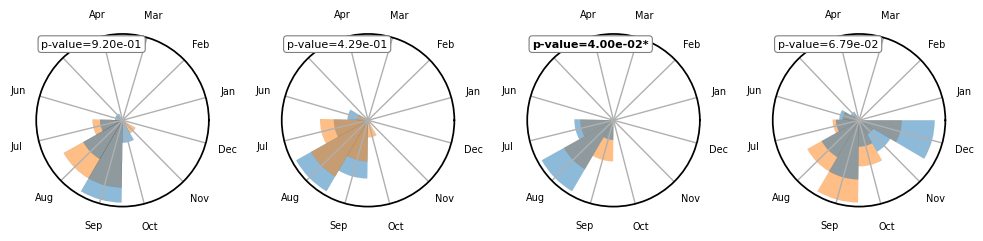

In [15]:
p_seas = tca.plot_diff_in_seasonality(analogues, pal)

In [16]:
# Summarize p-values
pvals = pd.DataFrame(columns = analogues.keys())
pvals.loc["Frequency"] = p_freq
pvals.loc["Wind"] = p_wind
pvals.loc["SLP"] = p_pres
pvals.loc["Seasonality"] = p_seas
pvals.loc["Translation Speed"] = p_speed
pvals.round(2)

,IBTrACS,CHAZ,MIT,SEAS520C
Frequency,0.89,0.70,0.75,0.94
Wind,0.09,0.65,0.32,0.13
SLP,0.73,NaN,NaN,0.96
Seasonality,0.92,0.43,0.04,0.07
Translation Speed,0.46,0.00,0.56,0.33


In [ ]:
# TODO When NCEI/NOAA is back up

# Global T anomaly from : https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/global/time-series/globe/tavg/land_ocean/12/0/1850-2025
globT = pd.read_csv("data/global_T.csv")
globT["year"] = globT.Date.astype(str).str.slice(0,4).astype(int)
globT["month"] = globT.Date.astype(str).str.slice(4,6).astype(int)

warming = {}
for c in catalogues:
    cf_start, cf_end, f_start, f_end = parameters.dates.loc[c]
    cf_mean = globT[(globT.year >= cf_start) & (globT.year <= cf_end)].Anomaly.mean()
    f_mean = globT[(globT.year >= f_start) & (globT.year <= f_end)].Anomaly.mean()
    warming[c] = f_mean - cf_mean
warming

plt.figure(figsize = (3,3))
for i, c in enumerate(catalogues):
    plt.scatter([i], mean[c]/warming[c], color = 'k', zorder = 10)
    print(mean[c]/warming[c])
    plt.plot([i,i], np.array(cis[c])/warming[c], color = 'k')
    print(np.array(cis[c])/warming[c])
plt.axhline(y=0, color = 'k', linestyle = "--")

plt.ylabel("m/s/°C")
plt.grid(axis = 'y')
plt.xticks(np.arange(4), catalogues.keys())
plt.title("Change in mean analogue wind speed per degrees of warming")